In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


In [31]:
# Define the paths
data_paths = {
    'Bearing Fault': 'E:/Cutting Tool Paper/Dataset/cutting tool data/cwt images data/Bearing Fault Data',
    'Gear Fault': 'E:/Cutting Tool Paper/Dataset/cutting tool data/cwt images data/Gear Fault Data',
    'Tool Fault': 'E:/Cutting Tool Paper/Dataset/cutting tool data/cwt images data/Tool Fault Data',
    'Normal': 'E:/Cutting Tool Paper/Dataset/cutting tool data/cwt images data/Normal Data'
}

# Function to load images and labels
def load_images_and_labels(data_paths):
    images = []
    labels = []
    for label, path in data_paths.items():
        for file in os.listdir(path):
            img_path = os.path.join(path, file)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
            img = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

images, labels = load_images_and_labels(data_paths)
print(len(images))
print(len(labels))


640
640


In [32]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

# One-hot encode the labels
labels_one_hot = tf.keras.utils.to_categorical(labels_encoded, num_classes=num_classes)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    rescale=1./255  # Normalizing the images
)

datagen.fit(images)


In [33]:


# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(images, labels_one_hot, test_size=0.2, random_state=42)


In [37]:
X_train.shape, X_val.shape

((512, 224, 224, 3), (128, 224, 224, 3))

In [38]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Load pre-trained VGG16 model + higher level layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Preprocess the images using VGG16's preprocessing
images = preprocess_input(images)


NameError: name 'num_classes' is not defined

In [8]:
# Reshape the features to fit LSTM input requirements
X_train_features = X_train_features.reshape(X_train_features.shape[0], 1, X_train_features.shape[1])
X_val_features = X_val_features.reshape(X_val_features.shape[0], 1, X_val_features.shape[1])


In [ ]:
from tensorflow.keras.layers import LSTM, Dense, Dropout

# LSTM model for temporal feature extraction
lstm_model = tf.keras.Sequential([
    LSTM(128, return_sequences=True, input_shape=(timesteps, feature_dim)),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [10]:
from deap import base, creator, tools, algorithms
import random

# Define evaluation function
def evaluate(individual):
    selected_features = [i for i in range(len(individual)) if individual[i] == 1]
    if len(selected_features) == 0:
        return 0,
    
    X_train_selected = X_train_lstm_features[:, selected_features]
    X_val_selected = X_val_lstm_features[:, selected_features]
    
    model = tf.keras.Sequential([
        Dense(64, activation='relu', input_dim=len(selected_features)),
        Dense(4, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train_selected, y_train, epochs=10, batch_size=8, verbose=0)
    
    _, accuracy = model.evaluate(X_val_selected, y_val, verbose=0)
    return accuracy,

# Define GA components
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=X_train_lstm_features.shape[1])
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# GA execution
population = toolbox.population(n=50)
algorithms.eaSimple(population, toolbox, cxpb=0.5, mutpb=0.2, ngen=10, verbose=True)

# Get the best individual
best_ind = tools.selBest(population, k=1)[0]
selected_features = [i for i in range(len(best_ind)) if best_ind[i] == 1]


C:\Users\Muhammad Umar\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:88: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


gen	nevals
0  	50    
1  	33    
2  	29    
3  	29    
4  	25    
5  	26    
6  	41    
7  	39    
8  	34    
9  	26    
10 	36    


In [17]:
# Select the features based on GA
X_train_selected = X_train_lstm_features[:, selected_features]
X_val_selected = X_val_lstm_features[:, selected_features]

# Define the final classification model
final_model = tf.keras.Sequential([
    Dense(64, activation='relu', input_dim=len(selected_features)),
    Dense(4, activation='softmax')
])

final_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the final model
history = final_model.fit(X_train_selected, y_train, epochs=50, batch_size=8, validation_data=(X_val_selected, y_val))


Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2942 - loss: 1.4044 - val_accuracy: 0.2812 - val_loss: 1.3806
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4005 - loss: 1.3422 - val_accuracy: 0.3281 - val_loss: 1.3640
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4234 - loss: 1.2980 - val_accuracy: 0.3594 - val_loss: 1.3339
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4723 - loss: 1.2406 - val_accuracy: 0.3750 - val_loss: 1.3139
Epoch 5/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4827 - loss: 1.1956 - val_accuracy: 0.3906 - val_loss: 1.2980
Epoch 6/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5024 - loss: 1.1571 - val_accuracy: 0.3906 - val_loss: 1.2890
Epoch 7/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4926 - loss: 1.1454 - val_accuracy: 0.3984 - val_loss: 1.2775
Epoch 8/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5733 - loss: 1.0724 - val_accuracy: 0.4062 - val_loss:

In [18]:
# Evaluate the model on the validation set
val_loss, val_accuracy = final_model.evaluate(X_val_selected, y_val)
print(f'Validation Accuracy: {val_accuracy*100:.2f}%')


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4792 - loss: 1.3642  
Validation Accuracy: 45.31%


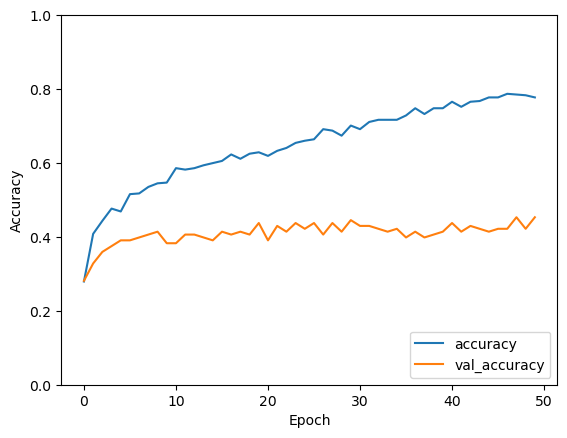

In [19]:
# Plot and save accuracy
plt.plot(history.epoch,history.history['accuracy'], label='accuracy')
plt.plot(history.epoch,history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right') 